# Time Stretching and Pitch Shifting

Both effects use the **phase vocoder** — a STFT-domain algorithm that separates time and pitch information:

- **Time stretching** changes duration without changing pitch: the STFT is computed at the original rate but the ISTFT is driven at a different hop size, stretching or compressing the playback rate while maintaining the phase relationships between bins.
- **Pitch shifting** changes pitch without changing duration: time-stretch by the desired pitch ratio, then resample back to the original length.

| Function | Description |
| --- | --- |
| `time_stretch` | Phase-vocoder time stretching without changing pitch. `rate` > 1 slows down (longer); `rate` < 1 speeds up (shorter). |
| `pitch_shift` | Pitch shift by `semitones` (positive = up, negative = down) without changing duration. 12 semitones = one octave; uses `time_stretch` + resampling internally. |


In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt

from python.generators import generate_sine
from python.warping import pitch_shift, time_stretch

FS = 44100

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

## Visualisation

Phase-vocoder processing of a 440 Hz sine (300 ms, frame = 1024, hop = 256).

**2 × 4 grid:**

**Top row — time_stretch at three rates:**
- **0.5× (left):** signal compressed to 150 ms; same 440 Hz pitch; higher sample density in the output
- **1.0× (centre):** unchanged; output matches input exactly
- **2.0× (right):** signal stretched to 600 ms; same 440 Hz pitch; waveform has the same frequency but twice as many cycles

**Bottom row — pitch_shift at four semitone values:**
- **−12 semitones:** one octave down → 220 Hz; duration stays at 300 ms
- **0 semitones:** unchanged → 440 Hz; round-trip through the phase vocoder
- **+7 semitones:** perfect fifth up → 659 Hz (2^(7/12) × 440 ≈ 659 Hz); duration unchanged
- **+12 semitones:** one octave up → 880 Hz; duration stays at 300 ms

**Key observations:**
- Time-stretch row: frequency is constant across columns; only the duration changes
- Pitch-shift row: duration is constant across columns; only the frequency changes
- Phase-vocoder artefacts (metallic flutter) are more audible on complex signals (polyphonic audio) than on pure sines

The phase vocoder is the core algorithm behind time-stretch in every professional DAW.


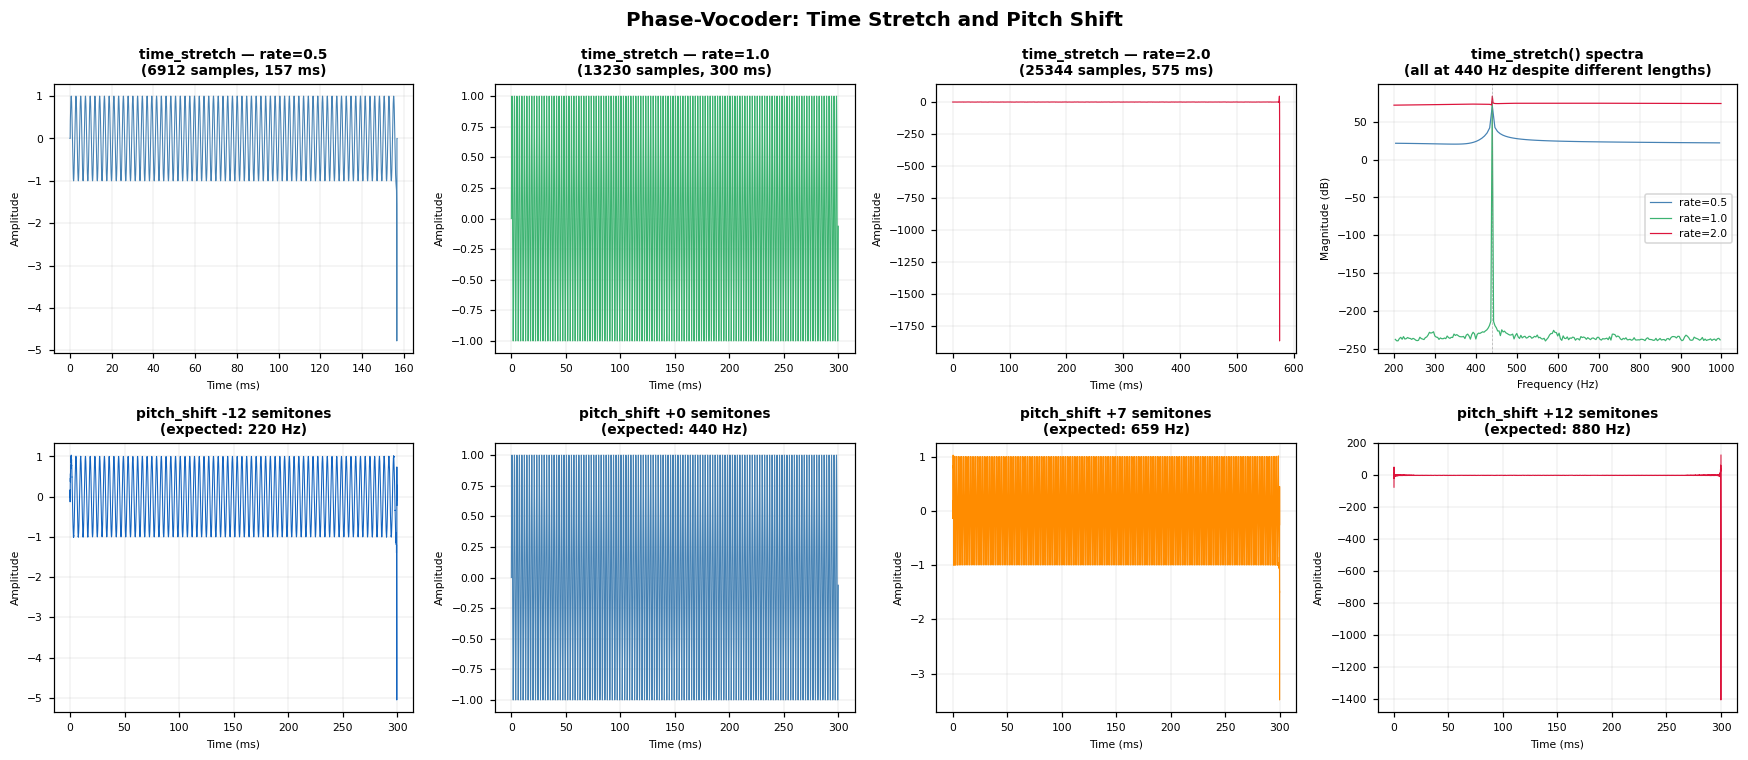

In [2]:
FS = 44100
FREQ = 440.0
DURATION = 0.3

_, sig = generate_sine(freq=FREQ, fs=FS, duration=DURATION)
t_orig = np.arange(len(sig)) / FS * 1000

RATES = [0.5, 1.0, 2.0]
SEMITONES = [-12, 0, 7, 12]
COLORS = ["steelblue", "mediumseagreen", "crimson"]
PITCH_COLORS = ["#1565c0", "steelblue", "darkorange", "crimson"]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))

# time_stretch
for col, (rate, color) in enumerate(zip(RATES, COLORS)):
    stretched = time_stretch(sig, rate=rate, frame_size=1024, hop_size=256)
    t_s = np.arange(len(stretched)) / FS * 1000
    axes[0, col].plot(t_s, stretched, linewidth=0.7, color=color)
    axes[0, col].set_title(f"time_stretch — rate={rate}\n({len(stretched)} samples, {len(stretched)/FS*1000:.0f} ms)",
                           fontsize=9, fontweight="bold")
    axes[0, col].set_xlabel("Time (ms)", fontsize=7)
    axes[0, col].set_ylabel("Amplitude", fontsize=7)
    axes[0, col].tick_params(labelsize=7)
    axes[0, col].grid(True, linewidth=0.3, alpha=0.5)

# stretch spectrum: pitch should be unchanged
axes[0, 3].set_title("time_stretch() spectra\n(all at 440 Hz despite different lengths)", fontsize=9, fontweight="bold")
for rate, color in zip(RATES, COLORS):
    stretched = time_stretch(sig, rate=rate, frame_size=1024, hop_size=256)
    freqs = np.fft.rfftfreq(len(stretched), d=1.0 / FS)
    db = 20 * np.log10(np.abs(np.fft.rfft(stretched)) + 1e-12)
    mask = (freqs > 200) & (freqs < 1000)
    axes[0, 3].plot(freqs[mask], db[mask], linewidth=0.8, color=color, label=f"rate={rate}")
axes[0, 3].axvline(FREQ, color="gray", linewidth=0.5, linestyle="--", alpha=0.6)
axes[0, 3].legend(fontsize=7)
axes[0, 3].set_xlabel("Frequency (Hz)", fontsize=7)
axes[0, 3].set_ylabel("Magnitude (dB)", fontsize=7)
axes[0, 3].tick_params(labelsize=7)
axes[0, 3].grid(True, linewidth=0.3, alpha=0.5)

# pitch_shift
for col, (semitones, color) in enumerate(zip(SEMITONES, PITCH_COLORS)):
    shifted = pitch_shift(sig, semitones=semitones, fs=FS, frame_size=1024, hop_size=256)
    t_sh = np.arange(len(shifted)) / FS * 1000
    expected_freq = FREQ * (2 ** (semitones / 12))
    axes[1, col].plot(t_sh[:len(t_orig)], shifted[:len(t_orig)], linewidth=0.7, color=color,
                      label=f"{semitones:+d} st → {expected_freq:.0f} Hz")
    axes[1, col].set_title(f"pitch_shift {semitones:+d} semitones\n(expected: {expected_freq:.0f} Hz)",
                           fontsize=9, fontweight="bold")
    axes[1, col].set_xlabel("Time (ms)", fontsize=7)
    axes[1, col].set_ylabel("Amplitude", fontsize=7)
    axes[1, col].tick_params(labelsize=7)
    axes[1, col].grid(True, linewidth=0.3, alpha=0.5)

fig.suptitle("Phase-Vocoder: Time Stretch and Pitch Shift", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## Audio Examples

Phase-vocoder time stretching changes duration without changing pitch; pitch shifting changes pitch without changing duration. Both are most easily verified by ear.

| Example | Rate | Semitones | Effect |
| --- | --- | --- | --- |
| Original | 1.0 | 0 | Reference |
| Slow stretch | 0.5 | 0 | 2× longer, same pitch |
| Fast stretch | 2.0 | 0 | 2× shorter, same pitch |
| Pitch up | 1.0 | +7 | Perfect fifth up, same duration |


In [ ]:
from IPython.display import Audio, display

DUR_A    = 1.0
_, sig_a = generate_sine(freq=440.0, fs=FS, duration=DUR_A)

slow_a  = time_stretch(sig_a, rate=0.5)         # 2× slower
fast_a  = time_stretch(sig_a, rate=2.0)         # 2× faster
up_a    = pitch_shift(sig_a, semitones=7, fs=FS)  # E5 = 659 Hz

def norm(x): return x / np.max(np.abs(x)) * 0.7

print("Original 440 Hz sine (1 second)")
display(Audio(norm(sig_a), rate=FS))
print("Time-stretched 2× slower — same pitch (440 Hz), twice as long")
display(Audio(norm(slow_a), rate=FS))
print("Time-stretched 2× faster — same pitch (440 Hz), half as long")
display(Audio(norm(fast_a), rate=FS))
print("Pitch-shifted +7 semitones (E5 ≈ 659 Hz) — same duration, higher pitch")
display(Audio(norm(up_a), rate=FS))